In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import sys
from copy import deepcopy

import urllib.request
import os

In [2]:
def line_box_intersection(line_start, line_end, box_min, box_max):
    """
    Finds the intersection points of a line segment and an axis-aligned bounding box (AABB).

    Args:
        line_start (np.array): The start point of the line (e.g., np.array([x, y, z])).
        line_end (np.array): The end point of the line (e.g., np.array([x, y, z])).
        box_min (np.array): The minimum corner of the box (e.g., np.array([xmin, ymin, zmin])).
        box_max (np.array): The maximum corner of the box (e.g., np.array([xmax, ymax, zmax])).

    Returns:
        list: A list of intersection points (up to two points).
    """
    #thanks Google's AI
    
    line_dir = line_end - line_start
    
    # Pre-calculate inverse direction components to replace division with multiplication (faster)
    # Handle cases where a component is zero
    inv_dir = np.array([1/line_dir[i] if line_dir[i] != 0 else np.inf for i in range(len(line_dir))])

    t_min = -np.inf
    t_max = np.inf
    
    intersection_points = []

    for i in range(len(line_start)): # Iterate over x, y, z dimensions
        t1 = (box_min[i] - line_start[i]) * inv_dir[i]
        t2 = (box_max[i] - line_start[i]) * inv_dir[i]

        # Ensure t1 is the smaller intersection parameter
        if t1 > t2:
            t1, t2 = t2, t1

        # Update the overall t_min and t_max for the intersection interval
        t_min = max(t_min, t1)
        t_max = min(t_max, t2)

        # If t_min becomes greater than t_max, the line does not intersect the box
        if t_min > t_max:
            return []
    
    # The line intersects the box. The intersection occurs between t_min and t_max.
    # The actual points of entry and exit within the original line segment range [0, 1] are determined here.

    # Clamp t_min and t_max to the line segment range [0, 1] if you're working with a segment
    # If using an infinite line, skip this clamping step.
    t_start = max(0, t_min)
    t_end = min(1, t_max)

    if t_start <= t_end:
        # Calculate intersection points
        if t_start >= 0 and t_start <= 1:
            points = line_start + t_start * line_dir
            intersection_points.append(points)
        if t_end >= 0 and t_end <= 1 and t_end != t_start: # Avoid adding the same point twice
            points = line_start + t_end * line_dir
            intersection_points.append(points)   
    return intersection_points

def split_line_nd(start_point, end_point, num_points):
    """
    Generates num_points equally spaced along a line segment between 
    start_point and end_point in N dimensions.

    Args:
        start_point (iterable): The starting point (e.g., [x1, y1, z1])
        end_point (iterable): The ending point (e.g., [x2, y2, z2])
        num_points (int): The total number of points to generate (must be >= 2).

    Returns:
        np.ndarray: An array of shape (num_points, N) containing the points.
    """
    #thanks Google's AI
    if num_points < 2:
        return np.array([start_point, end_point])

    # Convert to numpy arrays for easier calculation
    p1 = np.array(start_point)
    p2 = np.array(end_point)
    
    # Generate the interpolation factors (0 to 1)
    # The number of steps is num_points - 1
    t = np.linspace(0, 1, num_points)

    # Linear interpolation formula: P(t) = P1 + t * (P2 - P1)
    # The result will be an array of points
    points = p1 + t[:, np.newaxis] * (p2 - p1)
    
    return points

def getcpoints(x0,u,num_segments=5):
    x1=x0+u

    box_min = np.zeros_like(x0)
    box_max = np.ones_like(x0)
    intersection_points = line_box_intersection(x0, x1, box_min, box_max)
    if len(intersection_points) == 2:
        start,end = intersection_points
        result_points = split_line_nd(start, end, num_segments)
        return(result_points)
    else: 
        print("intersection_points NOT found")
        return(None)
    
def compress(X,c=1):
    c=1-c
    if c==1:
        return X
    dout = X.shape[1]
    
    # Calculate L1 norm for each output channel
    if len(X.shape)==2:
        Xvalues = torch.abs(X)
    elif len(X.shape)==4:
        Xvalues = torch.sum(torch.abs(X), dim=(2, 3))

    #print(Xvalues.shape)
    
    # Calculate how many channels to prune
    k = int(dout * c)

    x, i = torch.topk(Xvalues, k, dim=1)
    mask = torch.zeros_like(Xvalues,dtype=torch.int)
    src = torch.ones_like(i,dtype=torch.int)
    mask.scatter_(1, i, src)
    #print(Xvalues,x,i)
    #print(mask)
    if len(X.shape)==2:
        return mask*X
    else:
        #print(mask.shape,X.shape)
        #print(mask)
        mask=mask.unsqueeze(2)
        mask=mask.unsqueeze(3)
        mask=mask.repeat((1,1,X.shape[2],X.shape[3]))
        return mask*X

In [3]:
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class LambdaLayer(nn.Module):
    """Lambda layer for option A shortcut"""
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option='A'):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(in_planes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            if option == 'A':
                # For CIFAR-10 ResNet paper uses option A
                self.shortcut = LambdaLayer(lambda x: F.pad(
                    x[:, :, ::2, ::2],
                    (0, 0, 0, 0, planes//4, planes//4),
                    "constant", 0))
            elif option == 'B':
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_planes, self.expansion * planes,
                              kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm2d(self.expansion * planes)
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 16

        self.conv1 = conv3x3(3, 16)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    #def forward(self, x):
    def forward(self, x, mode=None,pp=False,c=(0,0,0,0)):
        if c==None:
            c=(0,0,0,0)
        if mode=="compress":
            x=compress(x,c[0])
        out = F.relu(self.bn1(self.conv1(x)))
        if mode=="compress":
            out=compress(out,c[1])
        out = self.layer1(out)
        if mode=="compress":
            out=compress(out,c[2])
        out = self.layer2(out)
        if mode=="compress":
            out=compress(out,c[3])
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def resnet20():
    return ResNet(BasicBlock, [3, 3, 3])


def resnet32():
    return ResNet(BasicBlock, [5, 5, 5])


def resnet44():
    return ResNet(BasicBlock, [7, 7, 7])


def resnet56():
    return ResNet(BasicBlock, [9, 9, 9])


def resnet110():
    return ResNet(BasicBlock, [18, 18, 18])


def resnet1202():
    return ResNet(BasicBlock, [200, 200, 200])


In [4]:
def evaluate_model(model, val_loader, device, mode=None,c=None):

    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    correct = 0
    total = 0
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs, mode=mode,c=c)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            '''
            if (batch_idx + 1) % 50 == 0:
                print(f'Batch [{batch_idx + 1}/{len(val_loader)}], '
                      f'Accuracy: {100.*correct/total:.2f}%')
            '''
    
    accuracy = 100. * correct / total
    avg_loss = total_loss / len(val_loader)
    
    # accuracy: float, accuracy percentage
    # avg_loss: float, average loss
    return accuracy, avg_loss

In [5]:
# Configuration
model_name = 'resnet56'  # Change to: resnet20, resnet32, resnet44, resnet56, resnet110, resnet1202
batch_size = 128
num_workers = 2

In [6]:
# Model URLs (pretrained weights)
model_urls = {
    'resnet20': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet20-12fca82f.th',
    'resnet32': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet32-d509ac18.th',
    'resnet44': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet44-014dd654.th',
    'resnet56': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet56-4bfd9763.th',
    'resnet110': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet110-1d1ed7c2.th',
    'resnet1202': 'https://github.com/akamaster/pytorch_resnet_cifar10/raw/master/pretrained_models/resnet1202-f3b1deed.th'
}

In [7]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:
# Data preprocessing (same as training, but without augmentation for validation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10 test set as validation set
print('Loading CIFAR-10 test dataset...')
testset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform_test
)

val_loader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print(f'Test set size: {len(testset)}')

Loading CIFAR-10 test dataset...


Files already downloaded and verified
Test set size: 10000


In [9]:
# Create model
print(f'\nCreating {model_name} model...')

# Check if model_name is valid
if model_name not in model_urls:
    raise ValueError(f"Invalid model_name: {model_name}. Choose from: {list(model_urls.keys())}")

# Create model based on model_name
if model_name == 'resnet20':
    model = resnet20()
elif model_name == 'resnet32':
    model = resnet32()
elif model_name == 'resnet44':
    model = resnet44()
elif model_name == 'resnet56':
    model = resnet56()
elif model_name == 'resnet110':
    model = resnet110()
else:
    raise ValueError(f"Unknown model: {model_name}")
model = model.to(device)


Creating resnet56 model...


In [10]:
# Download and load pretrained weights
model_path = f'./pretrained_models/{model_name}.th'
os.makedirs('./pretrained_models', exist_ok=True)

if not os.path.exists(model_path):
    print(f'Downloading pretrained {model_name} weights...')
    urllib.request.urlretrieve(model_urls[model_name], model_path)
    print('Download complete!')

print(f'Loading pretrained weights from {model_path}...')
checkpoint = torch.load(model_path, map_location=device)

# Handle different checkpoint formats
if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# the pretrained weights were saved with a module. prefix 
# (which PyTorch adds when using nn.DataParallel for multi-GPU training). 
# The single model doesn't have this prefix.
# Remove 'module.' prefix if present (from DataParallel)
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith('module.'):
        name = k[7:]  # remove 'module.' prefix
    else:
        name = k
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
print('Weights loaded successfully!')

Download complete!
Loading pretrained weights from ./pretrained_models/resnet56.th...


/tmp/ipykernel_3090386/3606739106.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Weights loaded successfully!


In [11]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,} ({total_params/1e6:.2f}M)')


Total parameters: 853,018 (0.85M)


In [12]:
# Evaluate model
print(f'\nEvaluating {model_name} on CIFAR-10 test set...')
print('=' * 60)

accuracy, avg_loss = evaluate_model(model, val_loader, device)

#print('=' * 60)
print(f'\nFinal Results:')
print(f'Test Accuracy: {accuracy:.2f}%')
print(f'Test Error: {100 - accuracy:.2f}%')
print(f'Average Loss: {avg_loss:.4f}')


Evaluating resnet56 on CIFAR-10 test set...



Final Results:
Test Accuracy: 93.27%
Test Error: 6.73%
Average Loss: 0.3560


In [13]:
def verify_model(model, mode=None,c=None, verbose=False):
    # Evaluate model
    print(f'\nEvaluating {model_name} on CIFAR-10 test set...')
    print('=' * 60)

    ver_acc, ver_loss = evaluate_model(model, val_loader, device, mode,c)

    print('=' * 60)
    print(f'\nFinal Results:')
    print(f'Test Accuracy: {ver_acc:.2f}%')
    print(f'Test Error: {100 - ver_acc:.2f}%')
    print(f'Average Loss: {ver_loss:.4f}')

    return ver_acc, ver_loss

In [14]:
baseline_acc, baseline_loss = verify_model(model)


Evaluating resnet56 on CIFAR-10 test set...

Final Results:
Test Accuracy: 93.27%
Test Error: 6.73%
Average Loss: 0.3560


In [15]:
def run_experiments(model, compressions, max_segments):

    results = {}
    compresion_id = 0
    for compression in compressions:
        print(f"\n-------- Analyzing {compression}:")
        
        line_start_2d = np.array(compression[0])
        line_dir = np.array(compression[1])
        cpoints = getcpoints(line_start_2d,line_dir,max_segments)
        if cpoints is None:
            print(".... skipping ....")
            continue
        print("\n ---- CPOINTS: -----\n")
        print(cpoints)
        print("-----------------------\n")
        accuracies = []
        for ci in cpoints:
            ver_acc, ver_loss = verify_model(model, mode="compress",c=ci.tolist())
            accuracies.append(ver_acc)
            print(f"\n------  C point {ci} : {ver_acc:.2f}%\n")
        
        results[compresion_id] = accuracies
        compresion_id = compresion_id + 1
    return results

In [16]:
from sympy import Rational

def create_segments_list(p):
    if p == 1:
        return ['1']
    return [str(Rational(i, p - 1)) for i in range(p)]


In [21]:
xx = create_segments_list(8)
xx

['0', '1/7', '2/7', '3/7', '4/7', '5/7', '6/7', '1']

In [17]:
# Plotting
def plot_experiment_results(compressions, baseline_acc, results, model_name, max_segments):
    #segments = [f"{i}/{max_segments}" for i in range(1, max_segments + 1)]
    segments = create_segments_list(max_segments)
    
    # Define different markers for each line
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd', '|', '_']

    plt.figure(figsize=(10, 6))
    for idx, (compression_id, accuracies) in enumerate(results.items()):
        # Cycle through markers if there are more compressions than markers
        marker = markers[idx % len(markers)]
        plt.plot(segments, accuracies, marker=marker, label=compressions[compression_id], 
                 linewidth=2, markersize=8)

    plt.xlabel('Theta (θ)', fontsize=12)
    plt.ylabel('Verification Accuracy (%)', fontsize=12)
    plt.title(f'{model_name} - Accuracy vs Compression by segment', fontsize=14)
    
    plt.grid(True, alpha=0.3)
    plt.axhline(y=baseline_acc, color='r', linestyle='--', alpha=0.5, label='Baseline')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_compression.png', dpi=300)
    plt.show()

In [18]:

max_segments = 5


-------- Analyzing [[0, 0, 0, 0], [1, 0, 0, 0]]:

 ---- CPOINTS: -----

[[0.   0.   0.   0.  ]
 [0.25 0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.75 0.   0.   0.  ]
 [1.   0.   0.   0.  ]]
-----------------------


Evaluating resnet56 on CIFAR-10 test set...


/tmp/ipykernel_3090386/962634753.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  t1 = (box_min[i] - line_start[i]) * inv_dir[i]



Final Results:
Test Accuracy: 93.27%
Test Error: 6.73%
Average Loss: 0.3560

------  C point [0. 0. 0. 0.] : 93.27%


Evaluating resnet56 on CIFAR-10 test set...

Final Results:
Test Accuracy: 74.85%
Test Error: 25.15%
Average Loss: 1.6421

------  C point [0.25 0.   0.   0.  ] : 74.85%


Evaluating resnet56 on CIFAR-10 test set...

Final Results:
Test Accuracy: 55.51%
Test Error: 44.49%
Average Loss: 3.1454

------  C point [0.5 0.  0.  0. ] : 55.51%


Evaluating resnet56 on CIFAR-10 test set...

Final Results:
Test Accuracy: 10.00%
Test Error: 90.00%
Average Loss: 10.3261

------  C point [0.75 0.   0.   0.  ] : 10.00%


Evaluating resnet56 on CIFAR-10 test set...

Final Results:
Test Accuracy: 10.00%
Test Error: 90.00%
Average Loss: 10.3261

------  C point [1. 0. 0. 0.] : 10.00%


-------- Analyzing [[0, 0, 0, 0], [1, 1, 1, 1]]:

 ---- CPOINTS: -----

[[0.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25]
 [0.5  0.5  0.5  0.5 ]
 [0.75 0.75 0.75 0.75]
 [1.   1.   1.   1.  ]]
---------------

/tmp/ipykernel_3090386/11080160.py:13: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(segments, accuracies, marker=marker, label=compressions[compression_id],


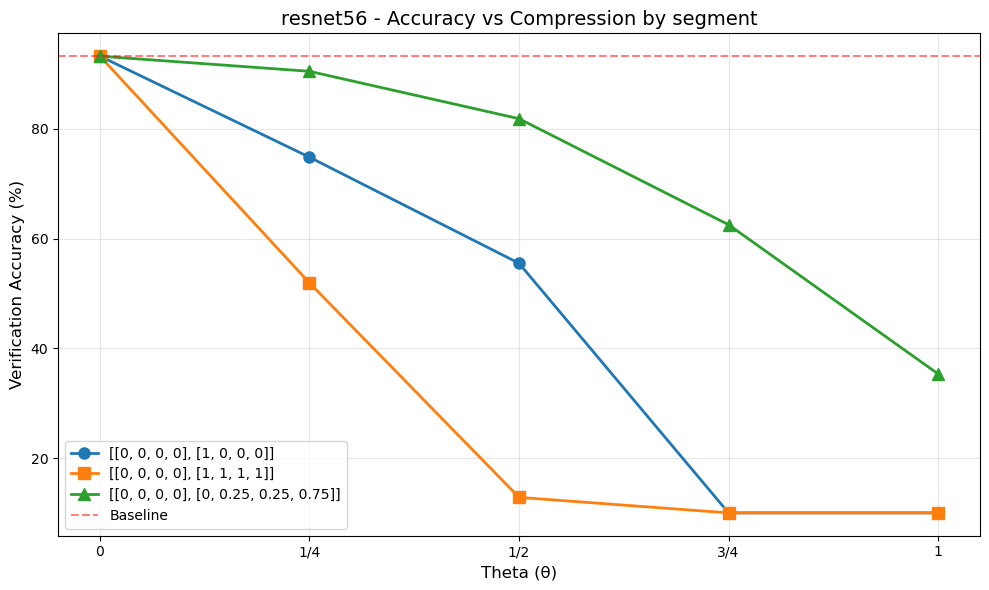

In [19]:
compressions = [[[0, 0, 0 ,0], [1, 0, 0, 0]],
                [[0, 0, 0 ,0], [1, 1, 1, 1]],
                [[0, 0, 0 ,0], [0, 0.25, 0.25, 0.75]],

]
results = run_experiments(model, compressions, max_segments)
plot_experiment_results(compressions, baseline_acc, results, model_name, max_segments)


C:\Users\nydor_pt\AppData\Local\Temp\ipykernel_26292\3605364437.py:12: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(segments, accuracies, marker=marker, label=compressions[compression_id],


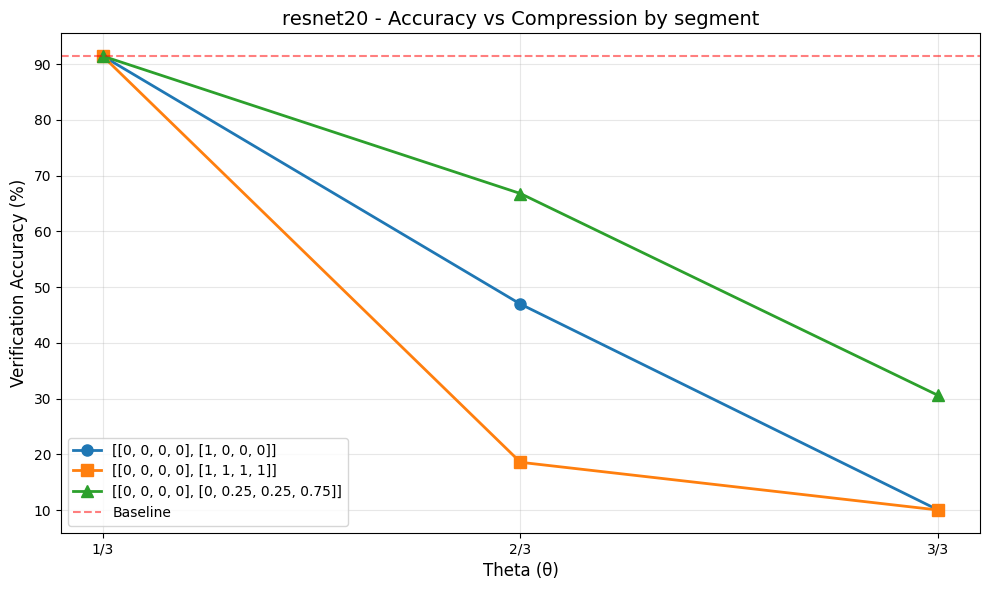

/tmp/ipykernel_4154780/999807503.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  t1 = (box_min[i] - line_start[i]) * inv_dir[i]



-------- Analyzing [[0, 0, 0, 0], [0, 0.75, 0.75, 0.75]]:

 ---- CPOINTS: -----

[[0.         0.         0.         0.        ]
 [0.         0.10714286 0.10714286 0.10714286]
 [0.         0.21428571 0.21428571 0.21428571]
 [0.         0.32142857 0.32142857 0.32142857]
 [0.         0.42857143 0.42857143 0.42857143]
 [0.         0.53571429 0.53571429 0.53571429]
 [0.         0.64285714 0.64285714 0.64285714]
 [0.         0.75       0.75       0.75      ]]
-----------------------



Evaluating: 100%|██████████| 79/79 [00:15<00:00,  5.25it/s]



Verification Test:
  Verification Loss: 1.1054
  Verification Accuracy: 77.17%

------  C point [0. 0. 0. 0.] : 77.17%



Evaluating: 100%|██████████| 79/79 [00:12<00:00,  6.31it/s]


...


Verification Test:
  Verification Loss: 4.6367
  Verification Accuracy: 37.32%

------  C point [0.35714286 0.71428571 0.71428571 0.17857143] : 37.32%



Evaluating: 100%|██████████| 79/79 [00:13<00:00,  5.78it/s]



Verification Test:
  Verification Loss: 5.7127
  Verification Accuracy: 25.21%

------  C point [0.42857143 0.85714286 0.85714286 0.21428571] : 25.21%



Evaluating: 100%|██████████| 79/79 [00:11<00:00,  6.69it/s]
/tmp/ipykernel_4154780/2600637697.py:12: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(segments, accuracies, marker='o', label=compressions[compression_id], linewidth=2)



Verification Test:
  Verification Loss: 4.4169
  Verification Accuracy: 10.00%

------  C point [0.5  1.   1.   0.25] : 10.00%



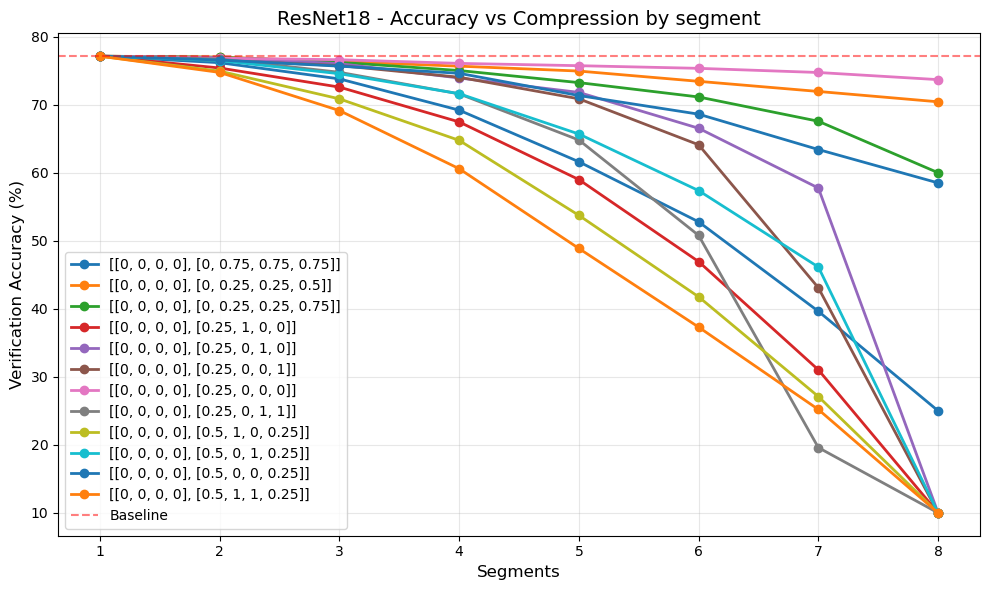

In [47]:
compressions = [
                [[0, 0, 0 ,0], [0, 0.75, 0.75, 0.75]],
                [[0, 0, 0 ,0], [0, 0.25, 0.25, 0.5]],
                [[0, 0, 0 ,0], [0, 0.25, 0.25, 0.75]],
                [[0, 0, 0 ,0], [0.25, 1, 0, 0]],
                [[0, 0, 0 ,0], [0.25, 0, 1, 0]],
                [[0, 0, 0 ,0], [0.25, 0, 0, 1]],
                [[0, 0, 0 ,0], [0.25, 0, 0 ,0]],
                [[0, 0, 0 ,0], [0.25, 0, 1, 1]],
                [[0, 0, 0 ,0], [0.5, 1, 0, 0.25]],
                [[0, 0, 0 ,0], [0.5, 0, 1, 0.25]],
                [[0, 0, 0 ,0], [0.5, 0, 0, 0.25]],
                [[0, 0, 0 ,0], [0.5, 1, 1 ,0.25]],
                ]
results = run_experiments(model, compressions, max_segments)
plot_experiment_results(checkpoint, results, model_name, max_segments)